**Goal:** answer Zachary's question -- can the friendship structure alone recover the karate club's two
real factions? You will score a grouping with **modularity**, let **Louvain** and greedy modularity
**find** communities, check the result against the real split with **NMI**, and contrast community
detection with **graph partitioning**. Same graph as L25 (the built-in karate club). Pairs with the
concept note [Community Detection in Networks](l26_concept_community_detection.qmd).

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devomh/cdat4001-2026/blob/main/u07_social_networks/l26_lab_community_detection.ipynb)

> This page is the read-only view. To run the lab, open the notebook
> (`l26_lab_community_detection.ipynb`) -- in Colab via the badge above, or
> locally. No data download is needed: the graph is built into NetworkX. Every
> text output below comes from actually running the cells.

## Prerequisites & Setup

We reuse **Zachary's Karate Club** from L25. NetworkX ships the community-detection algorithms in
`networkx.algorithms.community`, and we use scikit-learn's `normalized_mutual_info_score` to compare a
detected grouping with the ground truth. The Louvain method is randomized, so we pass a fixed `seed` for
reproducibility (the deterministic greedy and Kernighan-Lin results anchor the numbers).

In [1]:
# Setup cell 1 of 2: install only (Colab resets on open; run this first)
%pip install -q networkx scikit-learn pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup cell 2 of 2: imports + load the built-in graph. Safe to re-run.
import numpy as np
import pandas as pd
import networkx as nx
from networkx.algorithms import community as nxcom
from sklearn.metrics import normalized_mutual_info_score
from collections import Counter
import matplotlib.pyplot as plt

G = nx.karate_club_graph()
pos = nx.spring_layout(G, seed=42)   # same layout as L25
print("Karate Club:", G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges.")

Karate Club: 34 nodes, 78 edges.


<details><summary>Expected Output</summary>

~~~text
Karate Club: 34 nodes, 78 edges.
~~~
</details>

## Step 1 -- The ground truth: two real factions

The club really did split in two. NetworkX stores which faction each member joined in the `club` node
attribute ("Mr. Hi" or "Officer"). We turn that into a 0/1 label per node -- our **ground truth** to test
the algorithms against.

In [3]:
truth = {n: (0 if G.nodes[n]["club"] == "Mr. Hi" else 1) for n in G.nodes()}
print("Faction sizes (0 = Mr. Hi, 1 = Officer):", dict(Counter(truth.values())))

gt_sets = [{n for n in G.nodes() if truth[n] == 0},
           {n for n in G.nodes() if truth[n] == 1}]
print("Mr. Hi's group:", len(gt_sets[0]), "members | Officer's group:", len(gt_sets[1]), "members")

Faction sizes (0 = Mr. Hi, 1 = Officer): {0: 17, 1: 17}
Mr. Hi's group: 17 members | Officer's group: 17 members


<details><summary>Expected Output</summary>

~~~text
Faction sizes (0 = Mr. Hi, 1 = Officer): {0: 17, 1: 17}
Mr. Hi's group: 17 members | Officer's group: 17 members
~~~
</details>

The split was almost even: 17 and 17.

## Step 2 -- Scoring a grouping with modularity

**Modularity** \(Q\) scores how community-like a grouping is: edges *inside* the groups versus what random
chance would put there. Higher means stronger communities; near 0 means no better than random. Let us
score the real split, then a deliberately bad one.

In [4]:
q_truth = nxcom.modularity(G, gt_sets)
print("Modularity of the REAL two-faction split: Q =", round(q_truth, 4))

# A bad grouping that ignores structure: split by even vs odd node id.
bad = [{n for n in G.nodes() if n % 2 == 0}, {n for n in G.nodes() if n % 2 == 1}]
print("Modularity of an arbitrary even/odd split:  Q =", round(nxcom.modularity(G, bad), 4))

Modularity of the REAL two-faction split: Q = 0.3914
Modularity of an arbitrary even/odd split:  Q = 0.0044


<details><summary>Expected Output</summary>

~~~text
Modularity of the REAL two-faction split: Q = 0.3914
Modularity of an arbitrary even/odd split:  Q = 0.0044
~~~
</details>

The real split scores `0.391` -- solidly community-like, so the friendships really did cluster around the
two leaders. The even/odd split scores `0.004` -- essentially zero, because it cuts straight across the
real groups and captures no structure. That contrast is what \(Q\) is for.

**Try it (completion).** Score a third grouping and see where it lands.

In [5]:
# Completion: split by node id order (first 17 vs last 17) and print its modularity.
# It lands BETWEEN the two above, because low/high ids loosely track the two factions.
# id_split = [set(list(G.nodes())[:17]), set(list(G.nodes())[17:])]
# print("id-order split: Q =", round(nxcom.modularity(G, id_split), 4))

## Step 3 -- Letting an algorithm find the communities

Now the real task: hand the graph to an algorithm and let it find the densest grouping -- *without* the
ground truth. **Louvain** maximizes modularity and chooses the number of communities itself.

In [6]:
louvain = nxcom.louvain_communities(G, seed=42)
print("Louvain found", len(louvain), "communities; Q =", round(nxcom.modularity(G, louvain), 4))
print("Community sizes:", sorted(len(c) for c in louvain))

greedy = list(nxcom.greedy_modularity_communities(G))
print("Greedy modularity found", len(greedy), "communities; Q =", round(nxcom.modularity(G, greedy), 4))

Louvain found 4 communities; Q = 0.4266
Community sizes: [4, 6, 10, 14]
Greedy modularity found 3 communities; Q = 0.411


<details><summary>Expected Output</summary>

~~~text
Louvain found 4 communities; Q = 0.4266
Community sizes: [4, 6, 10, 14]
Greedy modularity found 3 communities; Q = 0.411
~~~
</details>

Both find **more than two** groups -- and Louvain's `Q = 0.427` is *higher* than the real split's `0.391`.
That is the key idea: maximizing modularity rewards **finer** structure, so the algorithm subdivides each
faction into tighter sub-cliques. It is not wrong; it found a denser grouping than the social split. Let
us see it.

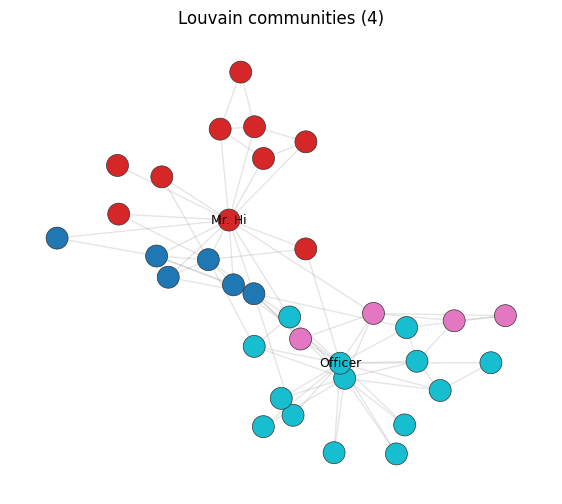

In [7]:
lou_label = {n: cid for cid, c in enumerate(louvain) for n in c}
colors = [lou_label[n] for n in G.nodes()]
plt.figure(figsize=(7, 6))
nx.draw_networkx_edges(G, pos, alpha=0.25, edge_color="#999999")
nx.draw_networkx_nodes(G, pos, node_color=colors, cmap=plt.get_cmap("tab10"),
                       node_size=250, edgecolors="#333333", linewidths=0.5)
nx.draw_networkx_labels(G, pos, labels={0: "Mr. Hi", 33: "Officer"}, font_size=9)
plt.title("Louvain communities (4)")
plt.axis("off")
plt.show()

**Try it (completion).** Read off the greedy result the same way Louvain was reported.

In [8]:
# Completion: print the number of greedy communities and their sizes.
# print("greedy communities:", len(greedy), "| sizes:", sorted(len(c) for c in greedy))

## Step 4 -- Did it get it right? Comparing to ground truth with NMI

We have a detected grouping and the real factions. **Normalized mutual information (NMI)** -- built on the
mutual information from L13 -- scores their agreement from 0 (none) to 1 (identical).

In [9]:
nodes = sorted(G.nodes())
truth_labels = [truth[n] for n in nodes]
lou_labels = [lou_label[n] for n in nodes]
print("NMI(Louvain 4-community, real 2-faction split):",
      round(normalized_mutual_info_score(truth_labels, lou_labels), 4))

NMI(Louvain 4-community, real 2-faction split): 0.5942


<details><summary>Expected Output</summary>

~~~text
NMI(Louvain 4-community, real 2-faction split): 0.5942
~~~
</details>

A moderate `0.59`: Louvain recovered the factions but then subdivided them, which costs agreement. So let
us ask for **exactly two** communities and compare again.

In [10]:
two = list(nxcom.greedy_modularity_communities(G, cutoff=2, best_n=2))
two_label = {n: cid for cid, c in enumerate(two) for n in c}
two_labels = [two_label[n] for n in nodes]
print("Forcing two communities -> sizes", sorted(len(c) for c in two))
print("NMI(two communities, real split):",
      round(normalized_mutual_info_score(truth_labels, two_labels), 4))

# Which members landed on the 'wrong' side of the real split?
maj = {cid: Counter(truth[n] for n in c).most_common(1)[0][0] for cid, c in enumerate(two)}
misplaced = sorted(n for n in nodes if maj[two_label[n]] != truth[n])
print("Members on the wrong side of the real split:", misplaced, "->", len(misplaced), "of 34")

Forcing two communities -> sizes [17, 17]
NMI(two communities, real split): 0.6772
Members on the wrong side of the real split: [8, 9] -> 2 of 34


<details><summary>Expected Output</summary>

~~~text
Forcing two communities -> sizes [17, 17]
NMI(two communities, real split): 0.6772
Members on the wrong side of the real split: [8, 9] -> 2 of 34
~~~
</details>

**This is Zachary's answer.** From the friendship graph alone -- no knowledge of the conflict -- the
two-community grouping recovers the real factions with only **2 of 34** members misplaced. The structure
nearly predicted the split. Let us see the detected two against the truth.

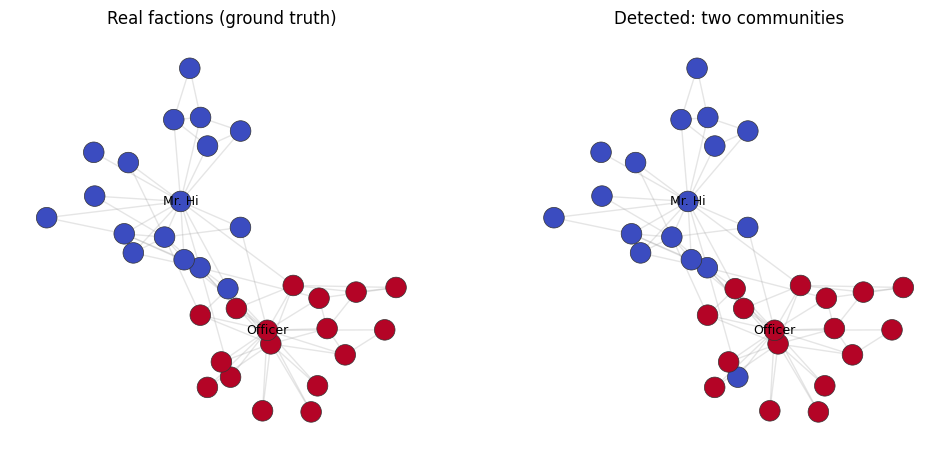

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
for ax, labels, title in [(axes[0], truth_labels, "Real factions (ground truth)"),
                          (axes[1], two_labels, "Detected: two communities")]:
    nx.draw_networkx_edges(G, pos, alpha=0.25, edge_color="#999999", ax=ax)
    nx.draw_networkx_nodes(G, pos, node_color=labels, cmap=plt.get_cmap("coolwarm"),
                           node_size=220, edgecolors="#333333", linewidths=0.5, ax=ax)
    nx.draw_networkx_labels(G, pos, labels={0: "Mr. Hi", 33: "Officer"}, font_size=9, ax=ax)
    ax.set_title(title); ax.axis("off")
plt.show()

**Try it (completion).** Measure how well the *Louvain* and *greedy* groupings agree with each other.

In [12]:
# Completion: build greedy labels and compute NMI between Louvain and greedy.
# gre_label = {n: cid for cid, c in enumerate(greedy) for n in c}
# print("NMI(Louvain, greedy):",
#       round(normalized_mutual_info_score(lou_labels, [gre_label[n] for n in nodes]), 4))

## Step 5 -- A different goal: graph partitioning

Community detection lets group sizes vary by density. **Graph partitioning** asks a different question:
split the nodes into a fixed number of **balanced** parts while cutting **as few edges as possible**. The
**Kernighan-Lin** heuristic does the two-way case.

In [13]:
part0, part1 = nxcom.kernighan_lin_bisection(G, seed=42)
cut = list(nx.edge_boundary(G, part0, part1))
print("Kernighan-Lin partition sizes:", sorted([len(part0), len(part1)]))
print("Edge-cut (edges crossing between the two parts):", len(cut))
print()
print("Community detection sizes (Louvain):", sorted(len(c) for c in louvain), "<- vary by density")
print("Partition sizes (Kernighan-Lin):    ", sorted([len(part0), len(part1)]), "<- forced balanced")

Kernighan-Lin partition sizes: [17, 17]
Edge-cut (edges crossing between the two parts): 10

Community detection sizes (Louvain): [4, 6, 10, 14] <- vary by density
Partition sizes (Kernighan-Lin):     [17, 17] <- forced balanced


<details><summary>Expected Output</summary>

~~~text
Kernighan-Lin partition sizes: [17, 17]
Edge-cut (edges crossing between the two parts): 10
Community detection sizes (Louvain): [4, 6, 10, 14] <- vary by density
Partition sizes (Kernighan-Lin):     [17, 17] <- forced balanced
~~~
</details>

Kernighan-Lin returns **balanced halves** (17 and 17) cutting only **10** edges. Here it happens to match
the social split too, but the *goal* differs: partitioning wants balanced parts with the fewest crossing
edges (think sharding a graph across servers), while community detection wants the natural dense groups,
whatever their sizes.

## Your Turn (Exercises)

### Exercise 1 -- Is Louvain stable?

In [14]:
# TODO: run nxcom.louvain_communities(G, seed=7) and compare to seed=42. Is the modularity
# Q still about 0.43? Are Mr. Hi (node 0) and the Officer (node 33) still in different
# communities? (Louvain is randomized; check how much the seed changes the answer.)

### Exercise 2 -- Name the holdouts

In [15]:
# TODO: the two-community detection misplaced 2 of the 34 members relative to the real split.
# Print those node ids (already computed as `misplaced`) and, using G.degree and
# list(G.neighbors(n)), look at who each is connected to. Why might structure put them
# on the other side from where they actually went?

### Exercise 3 -- Written: partition or detect?
For each task, say whether you would use **community detection** or **graph partitioning**, and why:
(a) splitting a 50-million-node social graph across 8 servers so that as few friendships as possible cross
between servers; (b) discovering interest-based groups of users for a "groups you might like" feature.
Two to three sentences total.

## Summary

- A **community** is dense inside, sparse outside; **modularity** \(Q\) scores how community-like a
  grouping is (the real karate split scores 0.391; an even/odd split, 0.004).
- **Community detection** (Louvain, greedy modularity) maximizes \(Q\) and **picks the number of groups
  itself** -- here it finds 4, finer than the 2 real factions, because finer splits raise \(Q\).
- **NMI** checks a grouping against ground truth (0 to 1). Forcing two communities recovers the real
  factions with only **2 of 34** members misplaced -- structure nearly predicted the fission.
- **Graph partitioning** (Kernighan-Lin) is a different goal: **balanced** parts with the minimum
  **edge-cut** (here 17/17, cut 10) -- for sharding and load-balancing, not for finding natural groups.
- **Unit VII complete:** L25 made the graph and measured local structure; L26 found the global structure
  and recovered a real social split from connections alone.